In [81]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import *
from keras.models import Sequential
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

In [92]:
mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [102]:
codings_size = 100
generator = Sequential([
    Dense(7 * 7 * 128),
    Reshape([7, 7, 128]),
    BatchNormalization(),
    Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh'),
])
discriminator = Sequential([
    Conv2D(64, kernel_size=5, strides=2, padding='same', activation=LeakyReLU(0.2)),
    Dropout(0.4),
    Conv2D(128, kernel_size=5, strides=2, padding='same', activation=LeakyReLU(0.2)),
    Dropout(0.4),
    Flatten(),
    Dense(1, activation='sigmoid')
])
gan = Sequential([generator, discriminator])

In [103]:
discriminator_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.002)
gan_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

discriminator.compile(loss="binary_crossentropy", optimizer=discriminator_optimizer)
discriminator.trainable = False
gan.compile(loss="binary_crossentropy", optimizer=gan_optimizer)

In [104]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(buffer_size=1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [105]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
	generator, discriminator = gan.layers
	for epoch in range(1, n_epochs+1):
		print(f"Epoch {epoch}/{n_epochs}")  # extra code
		for X_batch in dataset:
			# phase 1 - training the discriminator
			noise = tf.random.normal(shape=[batch_size, codings_size])
			generated_images = generator(noise)
			X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
			y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
			discriminator.trainable = True
			d_loss = discriminator.train_on_batch(X_fake_and_real, y1)
			discriminator.trainable = False
			# phase 2 - training the generator
			noise = tf.random.normal(shape=[batch_size, codings_size])
			y2 = tf.constant([[1.]] * batch_size)
			g_loss = gan.train_on_batch(noise, y2)

In [123]:
gan.save("./gan.keras")

In [106]:
train_gan(gan, dataset, batch_size, codings_size, n_epochs=50);

Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50


2025-05-07 19:05:27.971799: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50


In [107]:
generator.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (32, 6272)             │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (32, 7, 7, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (32, 7, 7, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (32, 14, 14, 64)       │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (32, 14, 14, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (32, 28, 28, 1)        │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840,705 (3.21 MB)

 Trainable params: 840,321 (3.21 MB)

 Non-trainable params: 384 (1.50 KB)

In [120]:
noise = tf.random.normal(shape=[batch_size, codings_size])
result = generator.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


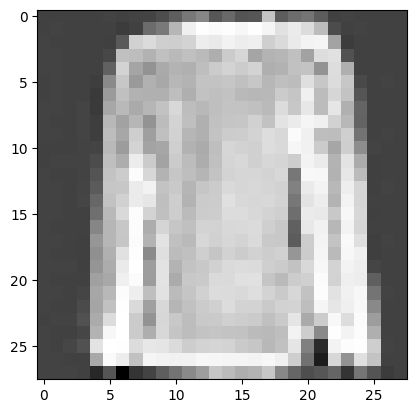

In [121]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(result[0], cmap='gray')
plt.show()